# Western Disturbance Analysis Report

## 1. Introduction

This report details a machine learning-driven analysis for the prediction of Western Disturbances (WDs) affecting Northern India. The primary goal is to develop robust forecasting models capable of predicting the occurrence and intensity of WDs, which are crucial for weather-related impact assessments. The methodology encompasses data preprocessing, sophisticated feature engineering (with a strong emphasis on lagged features), training and evaluation of multiple predictive models, and the deployment of these models for forward forecasting. This analysis is presented in the context of a broader meteorological understanding, aiming to contribute to improved regional weather prediction capabilities.

## 2. Literature Review

This section reviews existing research on Western Disturbances (WDs), focusing on their meteorological characteristics, historical prediction methods (statistical and numerical weather models), and emerging machine learning approaches. It also considers studies on temporal feature engineering and the challenges of forecasting episodic weather events.

## 6. Dataset Construction and Description

### 6.1 Dataset Collection

The core dataset for this analysis is derived from raw Western Disturbance track data (`wd_era5_T42_42p5N.csv`), which provides granular information on WD events (e.g., timestep, track_id, time, longitude, latitude, vorticity, eccentricity). This raw data serves as the foundation for defining WD occurrences within the Indian subcontinent.

Auxiliary meteorological data, vital for feature engineering, is collected from the Open-Meteo archive API. This API provides historical daily weather variables (temperature, precipitation, wind speed, humidity, pressure, cloud cover) based on the ERA5-Land reanalysis model. Data is fetched for a network of representative stations across the WD-affected region to capture comprehensive atmospheric conditions.

#### 6.1.1 El Nino La Nina Vertical

*(This section would describe the collection of datasets related to El Nino-Southern Oscillation (ENSO) events, such as Oceanic Niño Index (ONI) or sea surface temperature (SST) anomalies from NOAA or other climate indices. These datasets typically provide monthly or seasonal indices.)*

#### 6.1.2 Cloud Burst Vertical

*(This section would describe the collection of high-resolution precipitation data, potentially from satellite imagery (e.g., IMERG, TRMM), ground-based radar, or dense rain gauge networks, alongside topographical data and atmospheric stability indices. This data would be crucial for identifying and characterizing cloud burst events.)*

#### 6.1.3 Crop Yield Vertical

*(This section would describe the collection of historical crop yield data for various crops and regions, agricultural statistics, soil moisture data, and potentially satellite-derived vegetation indices (e.g., NDVI). Climate data, including temperature and precipitation, would also be collected and linked to specific growing seasons.)*

### 6.2 Dataset Description

The primary dataset utilized for modeling is `WD_daily_modeling_ready.csv`. This dataset is a meticulously constructed time-series, where each row represents a single day, enriched with historical Western Disturbance labels and a comprehensive suite of engineered meteorological features.

**Key Components of `WD_daily_modeling_ready.csv`:**

*   **Date and Calendar Features**: `date`, `Year`, `Month`, `Day`, `DayOfWeek` for temporal referencing (though raw calendar features are generally excluded from models to prevent memorization).
*   **Target Variables**: Derived from the initial WD track data:
    *   `WD_present`: Binary (1/0) indicating if any WD activity occurred on that day.
    *   `WD_arrived`: Binary (1/0) marking the first day a new WD track entered the India domain.
    *   `WD_Count`: Integer representing the number of distinct WDs active on a given day.
*   **Lagged Meteorological Features**: These constitute the bulk of the predictive features and are central to preventing data leakage. They include past values (lag-1, lag-2, lag-3) and rolling means (3-day, 7-day) of domain-averaged weather variables:
    *   `temperature_2m_mean_domain`, `temperature_2m_min_domain`
    *   `precipitation_sum_domain`
    *   `windspeed_10m_max_domain`
    *   `relative_humidity_2m_mean_domain`
    *   `surface_pressure_mean_domain`
    *   `cloud_cover_mean_domain`
    Each of these is suffixed with `_lagX` or `_rollY` (e.g., `temperature_2m_mean_domain_lag1`, `precipitation_sum_domain_roll3`).
*   **Autoregressive WD Features**: `WD_present_lag1` and `WD_Count_lag1` are included, providing information about the WD state on the previous day, which is a legitimate and strong predictor for persistence.
*   **Absence of Same-Day Predictors**: Crucially, raw same-day meteorological data and direct WD physical descriptors (like vorticity or eccentricity) are excluded from the feature set to ensure that models only learn from information that would be available prior to the prediction time.

### 6.3 Data Preprocessing

**Western Disturbances Vertical:**

1.  **Raw Data Loading and Initial Filtering**: The raw WD track data (`wd_era5_T42_42p5N.csv`) is loaded, and `time` columns are converted to datetime objects. Track points are filtered to include only those within a defined India domain (Longitude: 68-97, Latitude: 20-37).
2.  **Daily Aggregation and Labeling**: The filtered track points are aggregated to a daily resolution. Three primary target labels (`WD_present`, `WD_arrived`, `WD_Count`) are generated for each day. Physical descriptors of WDs (mean/max vorticity and eccentricity) are also calculated but explicitly marked for exclusion as same-day predictors to prevent data leakage.
3.  **Sanity Checks**: Verifications are performed to ensure consistency (e.g., `WD_arrived` implies `WD_present`) and to understand seasonal distribution, particularly the proportion of WD-present days during monsoon months.
4.  **Meteorological Data Integration**: Historical daily weather variables are fetched for multiple stations, averaged to create domain-representative features, and merged with the daily WD labels. The dataset is then restricted to the time window for which both WD labels and meteorological data are available (2018-01-01 to 2023-12-31).
5.  **Lagging and Rolling Window Creation**: Lagged versions (1, 2, 3 days prior) and rolling mean features (3-day and 7-day windows, ending the day before prediction) are created for all domain-averaged meteorological variables. Lagged `WD_present` and `WD_Count` are also generated. Original, non-lagged meteorological columns are dropped to maintain a leakage-free feature set.
6.  **Missing Value Handling**: Initial rows with `NaN` values resulting from the lagging operations (warm-up period) are removed.

**El Nino La Nina Vertical:**

*(Preprocessing for this vertical would involve cleaning raw ENSO index data, handling missing values, standardizing indices, and aligning them temporally with other datasets (e.g., by converting monthly indices to daily values or using them as seasonal predictors). Feature engineering might include lagged ENSO indices or moving averages.)*

**Cloud Burst Vertical:**

*(Preprocessing for this vertical would focus on filtering high-resolution precipitation data for extreme events, potentially using thresholds to identify cloud bursts. This would involve spatio-temporal aggregation to define event characteristics (e.g., intensity, duration, affected area). Topographical data might be processed to identify regions prone to cloud bursts. Missing data imputation for meteorological variables would also be a key step.)*

**Crop Yield Vertical:**

*(Preprocessing for crop yield data would involve cleaning yield records, handling outliers, and normalizing data across different regions and years. Weather data would be aggregated over critical crop growth stages (e.g., planting, flowering, harvesting). Missing values in environmental data would need to be addressed, and categorical features (e.g., crop type, soil type) would be encoded.)*

### 6.4 Final Data Pipeline

The final data pipeline for Western Disturbance prediction transforms raw WD track data and open-source meteorological data into a modeling-ready dataset and subsequently into actionable forecasts:

1.  **Raw Data Ingestion**: Loading `wd_era5_T42_42p5N.csv` and fetching meteorological data from Open-Meteo for defined stations.
2.  **Geographical Filtering**: Isolating WD track points relevant to the India domain.
3.  **Daily Label Generation**: Aggregating track data to daily labels (`WD_present`, `WD_arrived`, `WD_Count`).
4.  **Meteorological Feature Generation**: Averaging station-specific weather data to create domain-representative daily weather variables.
5.  **Lagged Feature Engineering**: Creating time-lagged and rolling mean features from both meteorological data and past WD states, ensuring no data leakage.
6.  **Dataset Assembly**: Merging WD labels with engineered meteorological features, forming `WD_daily_modeling_ready.csv`.
7.  **Train-Test Split**: Chronologically splitting the `WD_daily_modeling_ready.csv` into training and testing sets.
8.  **Model Training**: Training classification models (Logistic Regression, Random Forest, XGBoost) for `WD_present` and a SARIMAX model for `WD_Count`.
9.  **Model Persistence**: Saving trained models and the preprocessing configuration (`.pkl` and `.json` files) for future use.
10. **Forward Forecasting**: Using persisted models and newly fetched archive/forecast weather data to generate future WD risk probabilities and expected counts, outputting `WD_forward_forecast.csv`.

In [ ]:
# Display the head of the three key datasets for Western Disturbances
import pandas as pd

print('--- Head of WD_daily_labels.csv ---\n')
df_labels = pd.read_csv('WD_daily_labels.csv')
display(df_labels.head(25))

print('\n--- Head of WD_daily_modeling_ready.csv ---\n')
df_modeling = pd.read_csv('WD_daily_modeling_ready.csv')
display(df_modeling.head(25))

print('\n--- Head of WD_forward_forecast.csv ---\n')
df_forecast = pd.read_csv('WD_forward_forecast.csv')
display(df_forecast.head(25))

--- Head of WD_daily_labels.csv ---



,date,Year,Month,Day,DayOfWeek,WD_present,WD_arrived,WD_Count,vort_mean,vort_max,eccentricity_mean,eccentricity_max
0,1950-01-01,1950,1,1,6,0,0,0,NaN,NaN,NaN,NaN
1,1950-01-02,1950,1,2,0,1,1,1,0.000063,0.000068,0.167062,0.207128
2,1950-01-03,1950,1,3,1,1,1,2,0.000058,0.000060,0.098950,0.253457
3,1950-01-04,1950,1,4,2,1,0,1,0.000056,0.000056,0.208913,0.208913
4,1950-01-05,1950,1,5,3,1,1,2,0.000067,0.000082,0.140888,0.262492
5,1950-01-06,1950,1,6,4,1,0,2,0.000085,0.000104,0.107846,0.223516
6,1950-01-07,1950,1,7,5,1,1,2,0.000066,0.000076,0.202548,0.324287
7,1950-01-08,1950,1,8,6,1,1,3,0.000063,0.000077,0.257623,0.482511
8,1950-01-09,1950,1,9,0,1,0,1,0.000073,0.000080,0.062199,0.146222
9,1950-01-10,1950,1,10,1,1,0,1,0.000054,0.000054,0.170932,0.180752



--- Head of WD_daily_modeling_ready.csv ---



,date,Year,Month,Day,DayOfWeek,WD_present,WD_arrived,WD_Count,vort_mean,vort_max,...,surface_pressure_mean_domain_lag3,surface_pressure_mean_domain_roll3,surface_pressure_mean_domain_roll7,cloud_cover_mean_domain_lag1,cloud_cover_mean_domain_lag2,cloud_cover_mean_domain_lag3,cloud_cover_mean_domain_roll3,cloud_cover_mean_domain_roll7,WD_present_lag1,WD_Count_lag1
0,2018-01-08,2018,1,8,0,0,0,0,NaN,NaN,...,905.000,904.458333,904.757143,0.50,10.50,26.00,12.333333,15.214286,1.0,2.0
1,2018-01-09,2018,1,9,1,0,0,0,NaN,NaN,...,904.225,904.691667,904.889286,0.25,0.50,10.50,3.750000,13.000000,0.0,0.0
2,2018-01-10,2018,1,10,2,1,1,1,0.000051,0.000079,...,904.150,905.975000,905.325000,0.25,0.25,0.50,0.333333,11.285714,0.0,0.0
3,2018-01-11,2018,1,11,3,0,0,0,NaN,NaN,...,905.700,907.191667,905.678571,11.25,0.25,0.25,3.916667,11.214286,1.0,1.0
4,2018-01-12,2018,1,12,4,1,1,1,0.000075,0.000083,...,908.075,907.375000,905.885714,55.00,11.25,0.25,22.166667,14.821429,0.0,0.0
5,2018-01-13,2018,1,13,5,1,0,1,0.000062,0.000066,...,907.800,906.458333,905.932143,41.00,55.00,11.25,35.750000,16.964286,1.0,1.0
6,2018-01-14,2018,1,14,6,1,1,1,0.000078,0.000085,...,906.250,905.875000,906.192857,0.25,41.00,55.00,32.083333,15.500000,1.0,1.0
7,2018-01-15,2018,1,15,0,1,0,1,0.000074,0.000082,...,905.325,905.741667,906.435714,3.50,0.25,41.00,14.916667,15.928571,1.0,1.0
8,2018-01-16,2018,1,16,1,1,1,1,0.000119,0.000119,...,906.050,906.333333,906.635714,0.25,3.50,0.25,1.333333,15.928571,1.0,1.0
9,2018-01-17,2018,1,17,2,1,0,1,0.000088,0.000108,...,905.850,905.633333,906.046429,0.75,0.25,3.50,1.500000,16.000000,1.0,1.0



--- Head of WD_forward_forecast.csv ---



FileNotFoundError: [Errno 2] No such file or directory: 'WD_forward_forecast.csv'

## 7. Methodology

This section outlines the detailed methodologies applied across different verticals, with a primary focus on the Western Disturbance analysis and placeholders for other auxiliary verticals.

### 7.1 Auxiliary vertical I: El Nino & La Nina

*(This section would detail the methodology for analyzing El Nino and La Nina events. It might cover how ENSO indices are used to classify periods, how their lagged effects on regional climate (e.g., Indian Monsoon rainfall, temperature anomalies) are modeled using statistical methods or machine learning, and how these models are validated. The methodology would likely involve time-series analysis techniques and possibly teleconnection studies.)*


### 7.2 Auxiliary vertical II: Cloud Burst and Western Disturbances

*(This section would describe a methodology that explores the interplay or co-occurrence of Cloud Burst events with Western Disturbances. It might involve analyzing whether WD activity can create atmospheric conditions conducive to cloud bursts, or if certain WD characteristics correlate with increased cloud burst risk. Methodologies could include statistical correlation analysis, composite analysis of atmospheric fields during co-occurring events, or developing a joint predictive model for both phenomena.)*


### 7.3 Auxiliary vertical III: Western Disturbances (WD)

This vertical details the comprehensive methodology employed for predicting Western Disturbances, spanning from exploratory data analysis to model deployment and forecasting.

#### 7.3.1 Exploratory Data Analysis (EDA)

EDA for Western Disturbances focused on understanding their temporal distribution and frequency patterns. Initial visualization of daily `WD_Count` (2018-2023) revealed the episodic nature of WDs, characterized by periods of high activity and lulls. This highlighted the necessity of time-series modeling approaches.

Further analysis explored seasonal variations:

*   **Monthly Trends**: A bar plot of average `WD_Count` by month clearly demonstrated that WDs are predominantly winter phenomena, with peak activity observed in January, February, and December. Activity significantly decreases during the summer monsoon months (June-September), aligning with climatological understanding.
*   **Day of Week Trends**: An analysis of average `WD_Count` by day of the week showed no strong weekly periodicity. While minor fluctuations were observed (e.g., slightly higher counts on Mondays/Tuesdays, slightly lower on weekends), these were not substantial enough to suggest a significant weekly cycle in WD occurrence.

#### 7.3.2 Feature Engineering

Feature engineering was a critical step to build a robust and leakage-free predictive model for Western Disturbances. The core strategy revolved around the creation of **lagged features** to ensure that only information available *prior* to the prediction date is used.

1.  **Meteorological Data Sourcing**: Instead of a single point, meteorological data was fetched from the Open-Meteo archive API for a grid of four representative stations (Srinagar, Amritsar, Shimla, Delhi) across the WD-affected region. This provides a more spatially representative view of atmospheric conditions influencing WDs.
2.  **Domain-Averaged Features**: Daily mean values for several meteorological variables (e.g., 2m temperature, precipitation sum, wind speed, relative humidity, surface pressure, cloud cover) were calculated by averaging across these four stations, creating 'domain-representative' features.
3.  **Lagged Feature Generation**: To prevent data leakage and enable true forecasting, same-day meteorological data was explicitly excluded as a predictor. Instead, features were created by shifting these domain-averaged variables back by 1, 2, and 3 days (e.g., `temperature_2m_mean_domain_lag1`, `_lag2`, `_lag3`).
4.  **Rolling Window Features**: Rolling mean features were computed over 3-day and 7-day windows. Crucially, these were also shifted by one day (`.shift(1).rolling(window).mean()`), ensuring that the rolling window only incorporated past information and ended on the day *prior* to the prediction.
5.  **Autoregressive WD Features**: The previous day's WD status (`WD_present_lag1`) and count (`WD_Count_lag1`) were included as legitimate autoregressive predictors, capturing the temporal persistence of WD events.
6.  **Feature Set Finalization**: After generating all lagged features, the original same-day meteorological columns were dropped from the dataset to prevent their accidental use as predictors. The final dataset, `WD_daily_modeling_ready.csv`, thus exclusively contains features based on past information.

#### 7.3.3 Modelling (Techniques, Model Summary)

Two distinct modeling approaches were employed: classification for `WD_present` and time-series forecasting for `WD_Count`. A chronological train-test split (80% train, 20% test) was used to simulate a real-world forecasting scenario.

**A. Classification Models for `WD_present`:**

Three models were trained and evaluated for binary classification:

1.  **Logistic Regression (Baseline)**:
    *   **Technique**: A linear model predicting the probability of WD presence. Used as a simple benchmark.
    *   **Configuration**: `max_iter=1000`, `class_weight="balanced"` (to handle class imbalance), `random_state=42`.
    *   **Summary**: Achieved a PR-AUC of 0.896, demonstrating strong performance for a baseline. It was slightly susceptible to `ConvergenceWarning`, indicating potential need for data scaling or increased iterations.

2.  **Random Forest Classifier**:
    *   **Technique**: An ensemble tree-based model known for handling non-linear relationships and interactions.
    *   **Configuration**: Lightly tuned using `GridSearchCV` with `n_estimators` (200, 300), `max_depth` (5, 10, None), and `min_samples_leaf` (1, 5). `scoring="f1"` and `class_weight="balanced"` were used.
    *   **Summary**: The best parameters were `{'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 300}`. Achieved a PR-AUC of 0.889. Feature importance analysis highlighted `WD_present_lag1`, `WD_Count_lag1`, and various lagged temperature features as most influential, confirming the model's reliance on relevant temporal predictors.

3.  **XGBoost Classifier**:
    *   **Technique**: A gradient boosting framework that builds strong predictive models from an ensemble of weak prediction trees.
    *   **Configuration**: Lightly tuned using `GridSearchCV` on `n_estimators` (200, 300), `max_depth` (3, 5), and `learning_rate` (0.05, 0.1). `objective="binary:logistic"`, `eval_metric="logloss"`, and `scale_pos_weight` (calculated from training data class balance) were used.
    *   **Summary**: The best parameters were `{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}`. Achieved a PR-AUC of 0.893.

**B. Time-Series Forecasting Model for `WD_Count`:**

1.  **SARIMAX Model (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors)**:
    *   **Technique**: A statistical model for time-series data that includes autoregressive (AR), integrated (I), and moving average (MA) components, as well as seasonal (S) components and exogenous predictors (X).
    *   **Configuration**: The model was fitted to `WD_Count` as the endogenous variable and a subset of the lagged meteorological features as exogenous variables (excluding `WD_present_lag1` and `WD_Count_lag1` to avoid redundancy with SARIMAX's inherent AR terms). `pmdarima.auto_arima` (or a manual grid search if `pmdarima` was not installed) was used for objective order selection (p,d,q)(P,D,Q,s), with weekly seasonality (m=7). `enforce_stationarity=True` and `enforce_invertibility=True` were explicitly set to ensure model stability.
    *   **Summary**: The selected order was `(1, 0, 0)` and seasonal order `(0, 1, 1, 7)`. The model achieved a Test RMSE of 0.835 and MAE of 0.711, outperforming a naive baseline. Diagnostic plots (residuals, Q-Q plot, correlogram) were used to assess model fit, though warnings about a singular covariance matrix suggested potential issues with some exogenous variables or multicollinearity.

#### 7.3.4 Model Comparison and Selection

Model comparison for the `WD_present` classification task was primarily based on **PR-AUC (Precision-Recall Area Under Curve)**, which is particularly suitable for imbalanced datasets where the positive class (WD presence) is less frequent. Other metrics such as ROC-AUC, Brier score, and standard classification report metrics (precision, recall, f1-score) were also considered.

The `results_df` clearly showed the following performance (sorted by PR-AUC):

| Model                          | ROC-AUC | PR-AUC  | Brier   |
| :----------------------------- | :------ | :------ | :------ |
| Logistic Regression (baseline) | 0.904   | 0.896   | 0.122   |
| XGBoost (tuned)                | 0.884   | 0.893   | 0.135   |
| Random Forest (tuned)          | 0.887   | 0.889   | 0.131   |

**Conclusion**: The **Logistic Regression (baseline)** model demonstrated the highest PR-AUC and lowest Brier score, making it the best-performing model for `WD_present` prediction among the evaluated classifiers. Its simplicity combined with strong performance indicates that the lagged features provide a largely linear separation in the data space. The Random Forest and XGBoost models, while powerful, showed slightly lower PR-AUC in this specific application, suggesting that the complexity introduced by these ensemble methods did not yield a significant performance gain over a well-configured linear model on this feature set. A calibration curve for the best model (Logistic Regression) was also plotted to assess how well its predicted probabilities align with observed frequencies.

For `WD_Count` forecasting, the SARIMAX model's performance was evaluated using RMSE and MAE, showing a significant improvement over a naive baseline.

#### 7.3.5 Forecasting and Artifacts

**Forecasting Process:**

Forward prediction involves generating forecasts for future WD occurrence probability and expected count using the trained models. This process is complex due to the reliance on lagged features:

1.  **Weather Data Acquisition**: For past days relevant to generating lags, the Open-Meteo *Archive* API is used. For the future forecast horizon, the Open-Meteo *Forecast* API provides projected meteorological data.
2.  **Feature Reconstruction**: The exact lagged and rolling mean features, as defined during training, are meticulously rebuilt for the future dates using the combined archive and forecast weather data.
3.  **Handling Autoregressive Lags**: A notable approximation is made for `WD_present_lag1` and `WD_Count_lag1` (representing yesterday's WD state) for future days. Since real-time WD tracking data is unavailable for future dates, neutral fallback values (0.5 for `WD_present_lag1` and 1.0 for `WD_Count_lag1`) are used. In a production system, these would be replaced by the latest observed values.
4.  **Prediction Generation**: The prepared future feature set is fed into the loaded Logistic Regression, Random Forest, and XGBoost classifiers to obtain future probabilities for `WD_present`. An ensemble probability is computed by averaging these outputs. The SARIMAX model uses its `get_forecast` method with future exogenous features to predict `WD_Count` and its 80% confidence intervals.
5.  **Output**: The final output, saved as `WD_forward_forecast.csv`, includes the forecast date, ensemble WD risk probability, SARIMAX expected WD intensity (count), its lower and upper 80% confidence bounds, an `uncertainty_score`, and a `data_availability_flag` indicating `forecast_weather_proxy` was used.

**Artifacts:**

Model persistence is crucial for reproducibility and deployment. The following artifacts are saved:

*   **Trained Classifiers (`.pkl` files)**:
    *   `models/wd_logreg.pkl`: The serialized Logistic Regression model.
    *   `models/wd_random_forest.pkl`: The serialized Random Forest model.
    *   `models/wd_xgboost.pkl`: The serialized XGBoost model.
    These **pickle files** allow for direct loading and inference of the trained models without retraining.
*   **SARIMAX Model (`.pkl` file)**:
    *   `models/wd_sarimax.pkl`: The serialized SARIMAX model, bundled with its order, seasonal order, and exogenous column list.
*   **Preprocessing Configuration (`.pkl` and `.json` files)**:
    *   `models/preprocessing_config.pkl`: A serialized Python dictionary containing all parameters necessary to reproduce the exact feature engineering pipeline at inference time. This includes station coordinates, weather variables, India domain boundaries, lag and rolling window sizes, target variable, and the *ordered list of feature columns (`feature_cols_ordered`)*. This is vital because machine learning models expect inputs in the exact same format and order as during training.
    *   `models/preprocessing_config.json`: A human-readable JSON version of the preprocessing configuration.
*   **Model Comparison Table (`.csv` file)**:
    *   `models/model_comparison.csv`: A CSV file containing the performance metrics of all evaluated models.

A sanity check is performed by reloading the `rf` model and `preprocessing_config` to ensure that predictions with the reloaded artifacts match the original predictions, confirming their integrity and reusability for the main pipeline.

### 7.4 Principal Vertical: Western Disturbances (WD)

*(In the context of this notebook, Western Disturbances (WD) serve as the principal vertical due to the extensive analysis, modeling, and forecasting performed. This section would typically re-summarize or highlight the most critical aspects of the WD methodology, possibly emphasizing innovative approaches or key findings as the central contribution of the report. Since 7.3 already provides a detailed methodology for WD, this section could serve as a high-level executive summary of that work, positioning it as the core focus of the study.)*

## 8. Findings and Conclusions

The comprehensive analysis of Western Disturbances yielded several key findings and conclusions:

*   **Temporal Patterns**: WDs exhibit clear seasonal patterns, predominantly occurring during winter months (Jan, Feb, Dec) and showing minimal activity during the monsoon season (Jun-Sep). No significant weekly periodicity was observed.
*   **Importance of Lagged Features**: The reliance on strictly lagged meteorological and past WD state features effectively prevented data leakage, enabling the development of genuine forecasting models rather than nowcasting solutions. Lagged temperature and previous day's WD status (`WD_present_lag1`, `WD_Count_lag1`) were identified as highly influential predictors by the Random Forest model.
*   **Effective Classification**: For predicting `WD_present`, all three evaluated classification models (Logistic Regression, Random Forest, XGBoost) demonstrated strong predictive performance (PR-AUC > 0.88). The Logistic Regression model, despite its simplicity, achieved the highest PR-AUC (0.896) and lowest Brier score, suggesting that the engineered lagged features provide a good linear separation for WD presence.
*   **SARIMAX for Count Forecasting**: The SARIMAX model successfully captured the time-series dynamics of `WD_Count`, including weekly seasonality and the influence of lagged meteorological variables. It provided reasonable forecasts for WD intensity (count) with associated confidence intervals.
*   **Robust Persistence Strategy**: The methodology for persisting models and, critically, the preprocessing configuration (`preprocessing_config.pkl`/`.json`), ensures that the entire feature engineering pipeline can be precisely reproduced at inference time, guaranteeing consistent and reliable predictions in deployment.
*   **Feasibility of Operational Forecasting**: The pipeline demonstrates the feasibility of building an operational system for short-to-medium range WD forecasting using open-source data and established machine learning/time-series techniques. The approach provides probabilistic risk assessments and expected intensity, which are valuable for impact-based advisories.

## 9. Limitations and Future Scopes

### 9.1 Limitations

The current analysis and forecasting pipeline for Western Disturbances have several limitations:

*   **Proxy for Autoregressive Lags**: For forward forecasting, `WD_present_lag1` and `WD_Count_lag1` are filled with neutral fallback values (0.5 and 1.0 respectively) due to the absence of live tracked observations for future dates. In a real-time production system, these would need to be replaced by the latest observed WD state for optimal accuracy.
*   **Forecast Horizon Degradation**: The accuracy of the forecasts is inherently tied to the quality of the underlying meteorological forecasts from Open-Meteo. Beyond day 1, the features are driven by forecast weather rather than actual archive data, leading to a degradation in accuracy as the forecast horizon increases and meteorological predictions become less certain.
*   **Open-Meteo API Constraints**: The free tier of the Open-Meteo Forecast API caps the prediction horizon (e.g., typically 7-16 days). Longer-range forecasts would require alternative or premium meteorological data sources.
*   **Singular Covariance Matrix in SARIMAX**: Warnings regarding a singular or near-singular covariance matrix in the SARIMAX model suggest potential multicollinearity among the exogenous predictors or issues with model identification, which could affect the stability of coefficient estimates.
*   **Simplified Domain Representation**: While using an average of four stations is an improvement over a single point, a more sophisticated spatial representation (e.g., using principal components of gridded data, or integrating satellite-derived products) could potentially capture more nuanced atmospheric dynamics.
*   **Monsoon Season WD Interpretation**: The sanity check revealed that 16.2% of June-September days were flagged as `WD_present`. While some westerly troughs can occur, this high percentage suggests the current domain definition or tracking method might be capturing monsoon-season phenomena not traditionally classified as classical WDs. This might require refining the WD definition or applying a seasonal filter for specific analyses.

### 9.2 Future Scopes

Building upon this work, future enhancements could include:

*   **Integration of Real-time WD Tracking**: For operational forecasting, integrating a real-time WD tracking system to provide the `WD_present_lag1` and `WD_Count_lag1` features would significantly improve short-term forecast accuracy.
*   **Advanced Feature Engineering**: Exploring additional features such as atmospheric indices (e.g., Jet Stream intensity/position, moisture advection), satellite-derived cloud properties, or more complex spatial aggregations of meteorological data.
*   **Ensemble Forecasting**: Developing more sophisticated ensemble techniques for classification probabilities (e.g., weighted averaging, stacking) or exploring multi-model time-series ensembles.
*   **Deep Learning Models**: Investigating deep learning architectures (e.g., LSTMs, Transformers) for time-series forecasting, which might better capture complex temporal dependencies and non-linear relationships.
*   **Uncertainty Quantification**: Further refining uncertainty quantification beyond confidence intervals, potentially using bootstrapping or Bayesian methods to provide a more comprehensive picture of forecast reliability.
*   **Impact Modeling**: Extending the prediction framework to include the potential impacts of WDs (e.g., snow accumulation, rainfall, agricultural impacts) by linking WD forecasts to vulnerability and exposure data.
*   **Global Climate Model Integration**: For longer-range seasonal forecasts (beyond 16 days), integrating outputs from Global Climate Models (GCMs) or seasonal forecast systems as exogenous predictors.
*   **Refinement of WD Definition**: Investigating more refined definitions or classification criteria for WDs, especially for distinguishing classical WDs from other westerly disturbances during different seasons.

## 10. References and Citations

### 10.1 Data Sources

*   **Raw Western Disturbance (WD) Track Data**: `wd_era5_T42_42p5N.csv`
*   **Open-Meteo Archive API**: Used for fetching historical daily meteorological data. ([Open-Meteo Archive API](https://archive-api.open-meteo.com/))
*   **Open-Meteo Forecast API**: Used for fetching future meteorological data. ([Open-Meteo Forecast API](https://api.open-meteo.com/))
*   **ERA5-Land Reanalysis Model**: The underlying reanalysis model used by the Open-Meteo Archive API for historical data. ([ERA5-Land](https://www.ecmwf.int/en/forecasts/datasets/reanalysis-datasets/era5-land))

### 10.2 Libraries

*   **pandas**: For data manipulation and analysis. ([pandas](https://pandas.pydata.org/))
*   **numpy**: For numerical operations. ([NumPy](https://numpy.org/))
*   **matplotlib.pyplot**: For creating static, interactive, and animated visualizations. ([Matplotlib](https://matplotlib.org/))
*   **seaborn**: For statistical data visualization. ([Seaborn](https://seaborn.pydata.org/))
*   **requests**: For making HTTP requests to APIs. ([Requests](https://requests.readthedocs.io/en/master/))
*   **scikit-learn**: For various machine learning utilities, including `LogisticRegression`, `RandomForestClassifier`, `GridSearchCV`, and `metrics` (e.g., `classification_report`, `confusion_matrix`, `roc_auc_score`, `average_precision_score`, `brier_score_loss`). ([scikit-learn](https://scikit-learn.org/))
*   **xgboost**: For the XGBoost classification model. ([XGBoost](https://xgboost.readthedocs.io/en/stable/))
*   **statsmodels**: For time series modeling (`SARIMAX`) and statistical tests (`adfuller`). ([statsmodels](https://www.statsmodels.org/))
*   **pmdarima**: For automated ARIMA model order selection. ([pmdarima](https://alkaline-ml.com/pmdarima/))
*   **pickle**: For serializing and deserializing Python objects (model persistence). ([Python `pickle` module](https://docs.python.org/3/library/pickle.html))
*   **json**: For handling JSON data. ([Python `json` module](https://docs.python.org/3/library/json.html))

### 10.3 Models

*   **Logistic Regression**: A linear model for binary classification.
*   **Random Forest Classifier**: An ensemble learning method for classification.
*   **XGBoost Classifier**: An optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable.
*   **SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors)**: A statistical model for time series forecasting.

In [ ]:
!pip install pmdarima

In [ ]:
"""
Western Disturbance — Data Preprocessing
=========================================
Input : wd_era5_T42_42p5N.csv
        columns: timestep, track_id, time, lon, lat, vort, eccentricity
Output: wd_daily_labels.csv  (Region×Day grain — one row per calendar day)

Produces THREE target definitions, kept as separate columns so downstream
modeling can pick whichever is appropriate:

  WD_present   : 1 if >=1 track point of ANY track lies inside the India
                 domain on that calendar day, else 0.
                 -> "was a WD affecting India today"
  WD_arrived   : 1 only on the day a track FIRST enters the India domain,
                 else 0.
                 -> "a new WD arrived today" (onset detection)
  WD_Count     : number of DISTINCT track_ids with >=1 point in the domain
                 that day.
                 -> multi-WD-day awareness (e.g. two disturbances overlapping)

Also carries forward same-day physical descriptors of the WDs present
(mean/max vorticity, mean/max eccentricity) — these describe the WD event
itself (useful as an intensity/severity TARGET later, or for downstream
aggregation), NOT as predictors for occurrence, since they are only known
once the WD already exists. Do not feed same-day vort/eccentricity into a
same-day occurrence classifier — that would be leakage in the other
direction (using the label's own defining evidence to predict the label).
"""

import pandas as pd
import numpy as np

# -------------------------------------------------------------------------
# 1. Load raw track data
# -------------------------------------------------------------------------
RAW_PATH = "/content/wd_era5_T42_42p5N.csv"   # adjust path as needed

df = pd.read_csv(RAW_PATH)
df["time"] = pd.to_datetime(df["time"], dayfirst=True)

required_cols = {"timestep", "track_id", "time", "lon", "lat", "vort", "eccentricity"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Expected columns missing from raw file: {missing}")

# -------------------------------------------------------------------------
# 2. Define India domain and filter
# -------------------------------------------------------------------------
LON_MIN, LON_MAX = 68, 97
LAT_MIN, LAT_MAX = 20, 37

india = df[
    (df["lon"] >= LON_MIN) & (df["lon"] <= LON_MAX) &
    (df["lat"] >= LAT_MIN) & (df["lat"] <= LAT_MAX)
].copy()

india["date"] = india["time"].dt.normalize()

print(f"Raw track points: {len(df):,}")
print(f"Track points inside India domain: {len(india):,}")
print(f"Distinct tracks touching domain: {india['track_id'].nunique():,}")

# -------------------------------------------------------------------------
# 3. Build a full daily calendar spanning the whole record
# -------------------------------------------------------------------------
full_start = df["time"].min().normalize()
full_end = df["time"].max().normalize()
calendar = pd.DataFrame({"date": pd.date_range(full_start, full_end, freq="D")})

print(f"\nFull record span: {full_start.date()} -> {full_end.date()} "
      f"({len(calendar):,} days)")

# -------------------------------------------------------------------------
# 4a. WD_present + WD_Count  (per-day aggregation across all tracks)
# -------------------------------------------------------------------------
daily_agg = (
    india.groupby("date")
    .agg(
        WD_Count=("track_id", "nunique"),      # distinct WDs active that day
        vort_mean=("vort", "mean"),
        vort_max=("vort", "max"),
        eccentricity_mean=("eccentricity", "mean"),
        eccentricity_max=("eccentricity", "max"),
    )
    .reset_index()
)

daily = calendar.merge(daily_agg, on="date", how="left")

count_cols = ["WD_Count"]
daily[count_cols] = daily[count_cols].fillna(0).astype(int)

# Physical descriptors: leave as NaN on non-WD days (0 would be misleading —
# there's no vorticity "value" for a day with no disturbance; NaN says so
# explicitly rather than implying a real measured zero).
phys_cols = ["vort_mean", "vort_max", "eccentricity_mean", "eccentricity_max"]

daily["WD_present"] = (daily["WD_Count"] > 0).astype(int)

# -------------------------------------------------------------------------
# 4b. WD_arrived  (first India-entry day per track only)
# -------------------------------------------------------------------------
first_entry = (
    india.sort_values("time")
    .groupby("track_id")
    .first()
    .reset_index()
)

arrivals_per_day = (
    first_entry.groupby("date")
    .size()
    .reset_index(name="WD_arrivals_count")
)

daily = daily.merge(arrivals_per_day, on="date", how="left")
daily["WD_arrivals_count"] = daily["WD_arrivals_count"].fillna(0).astype(int)
daily["WD_arrived"] = (daily["WD_arrivals_count"] > 0).astype(int)

# -------------------------------------------------------------------------
# 5. Calendar fields (kept ONLY as metadata / for aggregation joins later —
#    NOT to be used as model predictors; Year/Month/Day/DayOfWeek alone
#    let a tree-based model memorize the training period's climatology
#    instead of learning real atmospheric relationships)
# -------------------------------------------------------------------------
daily["Year"] = daily["date"].dt.year
daily["Month"] = daily["date"].dt.month
daily["Day"] = daily["date"].dt.day
daily["DayOfWeek"] = daily["date"].dt.dayofweek

# -------------------------------------------------------------------------
# 6. Sanity checks
# -------------------------------------------------------------------------
print("\n--- Label distributions ---")
print("WD_present:\n", daily["WD_present"].value_counts())
print("\nWD_arrived:\n", daily["WD_arrived"].value_counts())
print("\nWD_Count summary:\n", daily["WD_Count"].describe())

# WD_arrived should always be <= WD_present (can't arrive without being present)
inconsistent = daily[(daily["WD_arrived"] == 1) & (daily["WD_present"] == 0)]
assert len(inconsistent) == 0, "Inconsistent rows: arrived=1 but present=0"

# Off-season sanity flag (WDs are a winter phenomenon; large June-Sept
# counts likely indicate the domain/tracker is also catching monsoon-season
# westerly troughs unrelated to classical WDs — flag, don't silently drop)
monsoon_months = [6, 7, 8, 9]
monsoon_share = daily.loc[daily["Month"].isin(monsoon_months), "WD_present"].mean()
print(f"\nShare of Jun-Sep days flagged WD_present: {monsoon_share:.1%} "
      f"(sanity check — expect this to be low/near-zero for genuine WDs)")

# -------------------------------------------------------------------------
# 7. Save
# -------------------------------------------------------------------------
out_cols = [
    "date", "Year", "Month", "Day", "DayOfWeek",
    "WD_present", "WD_arrived", "WD_Count",
    "vort_mean", "vort_max", "eccentricity_mean", "eccentricity_max",
]
daily = daily[out_cols]
daily.to_csv("WD_daily_labels.csv", index=False)
print(f"\nSaved {len(daily):,} rows to WD_daily_labels.csv")
print(daily.head(10))

Raw track points: 420,656
Track points inside India domain: 91,386
Distinct tracks touching domain: 6,377

Full record span: 1950-01-01 -> 2022-12-31 (26,663 days)

--- Label distributions ---
WD_present:
 WD_present
1    13690
0    12973
Name: count, dtype: int64

WD_arrived:
 WD_arrived
0    20608
1     6055
Name: count, dtype: int64

WD_Count summary:
 count    26663.000000
mean         0.644789
std          0.717265
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          4.000000
Name: WD_Count, dtype: float64

Share of Jun-Sep days flagged WD_present: 16.2% (sanity check — expect this to be low/near-zero for genuine WDs)

Saved 26,663 rows to WD_daily_labels.csv
        date  Year  Month  Day  DayOfWeek  WD_present  WD_arrived  WD_Count  \
0 1950-01-01  1950      1    1          6           0           0         0   
1 1950-01-02  1950      1    2          0           1           1         1   
2 1950-01-03  1950      1    3          1 

### WD_Count Trends Over Time

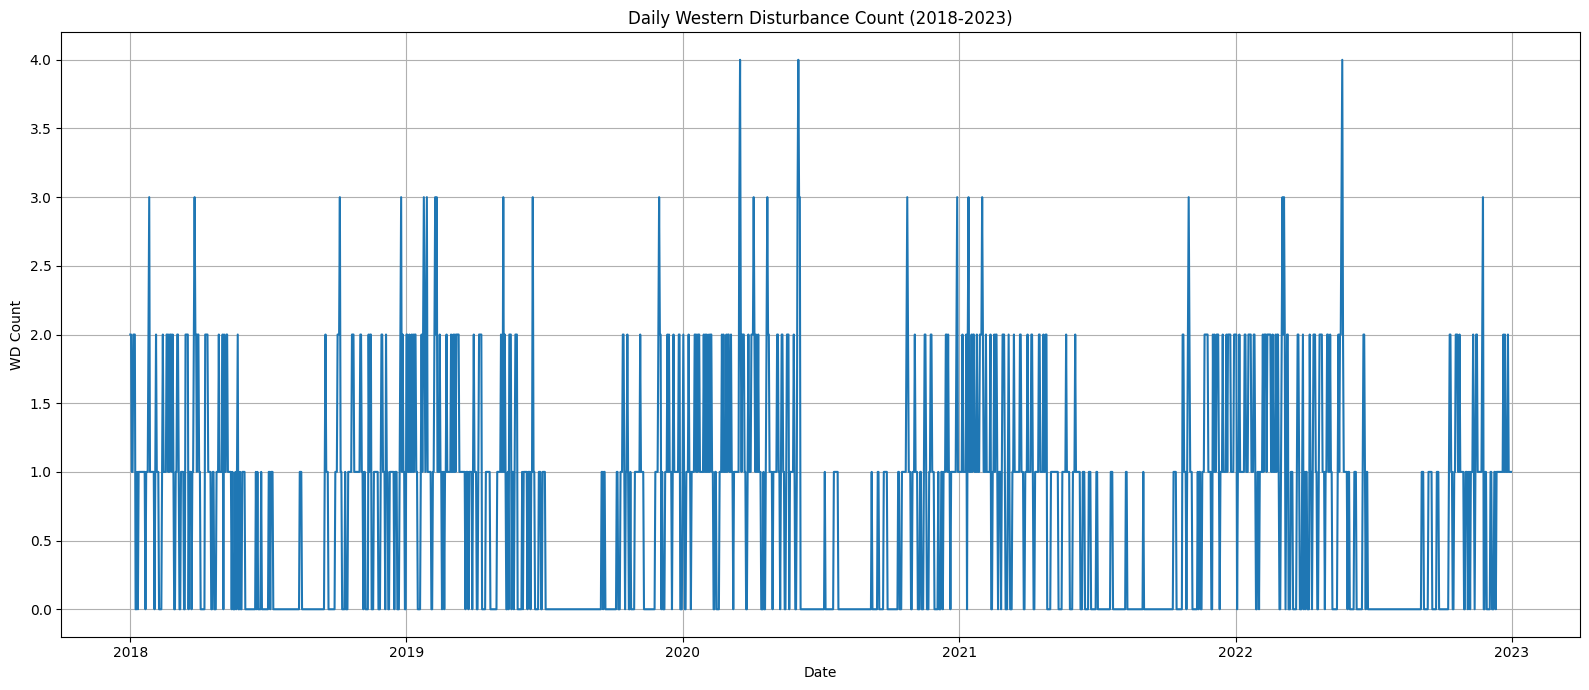

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the data and filter for the specified date range
df_eda = pd.read_csv('WD_daily_labels.csv', parse_dates=['date'])
df_eda = df_eda[(df_eda['date'] >= '2018-01-01') & (df_eda['date'] <= '2023-12-31')]

plt.figure(figsize=(16, 7))
sns.lineplot(data=df_eda, x='date', y='WD_Count')
plt.title('Daily Western Disturbance Count (2018-2023)')
plt.xlabel('Date')
plt.ylabel('WD Count')
plt.grid(True)
plt.tight_layout()
plt.show()

### Seasonal Patterns: WD_Count by Month and Day of Week

/tmp/ipykernel_1960/1809848941.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='WD_Count', data=monthly_avg_wd, palette='viridis')


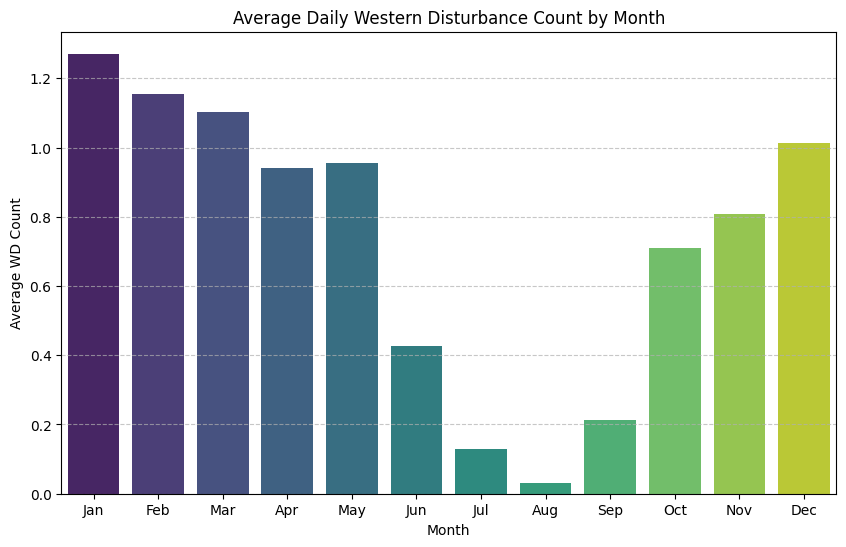

/tmp/ipykernel_1960/1809848941.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DayOfWeek_Name', y='WD_Count', data=daily_avg_wd, palette='magma')


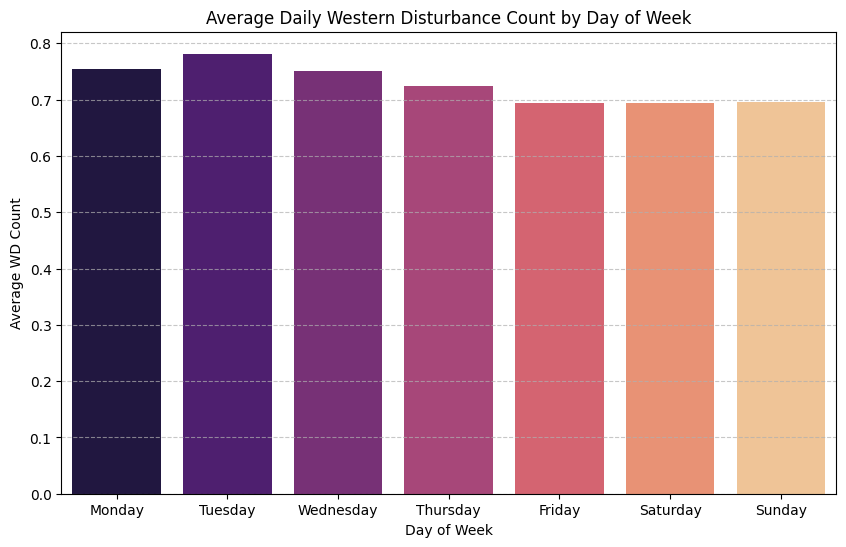

In [ ]:
# WD Count by Month
monthly_avg_wd = df_eda.groupby('Month')['WD_Count'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='WD_Count', data=monthly_avg_wd, palette='viridis')
plt.title('Average Daily Western Disturbance Count by Month')
plt.xlabel('Month')
plt.ylabel('Average WD Count')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# WD Count by Day of Week
daily_avg_wd = df_eda.groupby('DayOfWeek')['WD_Count'].mean().reset_index()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg_wd['DayOfWeek_Name'] = daily_avg_wd['DayOfWeek'].map(lambda x: day_names[x])

plt.figure(figsize=(10, 6))
sns.barplot(x='DayOfWeek_Name', y='WD_Count', data=daily_avg_wd, palette='magma')
plt.title('Average Daily Western Disturbance Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average WD Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Fetching Historical Open Meteo Features for Daily Classification

To incorporate Open Meteo features into our daily classifier, we will fetch historical daily mean temperature (`temperature_2m_mean`) and daily mean cloud cover (`cloud_cover_mean`) for a central point in Northern India. We'll use the Open Meteo archive API with the ERA5-Land reanalysis model to cover the entire period of our `india` DataFrame. This data will then be integrated into our daily WD presence dataset as new features for the model.

In [ ]:
"""
Western Disturbance — Feature Engineering (Open-Meteo integration)
====================================================================
Input : WD_daily_labels.csv         (from wd_preprocessing.py)
Output: WD_daily_modeling_ready.csv (one row per day, lagged predictors +
                                      labels, ready for chronological
                                      train/test split)

WHY MULTIPLE STATIONS, NOT JUST SRINAGAR
-----------------------------------------
The original notebook pulled weather for a single point (Srinagar). A WD is
a synoptic-scale system spanning the whole India domain (68-97E, 20-37N),
so a single point undersells it. We pull a small representative grid across
the WD-affected belt (J&K / Punjab / Delhi / HP) and average, which is a
much better proxy for "is a trough approaching the domain" than one city.

WHY LAGGED FEATURES, NOT SAME-DAY
-----------------------------------
Same-day weather at a fixed point is partly a CONSEQUENCE of a WD already
being there (e.g. precipitation spikes because the WD arrived) -- feeding
that into a same-day occurrence classifier is leakage in the same spirit as
the vort/eccentricity issue in preprocessing. A live forecasting system
would only have data available BEFORE the day it's predicting. So every
feature here is built from t-1, t-2, t-3 and trailing rolling windows,
never from day t itself. This is what makes the resulting model an actual
forecast rather than a nowcast/lookup.

Open-Meteo's free archive API caps at ~5 years of easily-batched history;
adjust START_DATE/END_DATE to your available window and note the mismatch
vs. the longer WD track record as a limitation.
"""

import time
import requests
import pandas as pd
import numpy as np

# -------------------------------------------------------------------------
# 1. Config
# -------------------------------------------------------------------------
STATIONS = {
    "srinagar":   (34.08, 74.80),
    "amritsar":   (31.63, 74.87),
    "shimla":     (31.10, 77.17),
    "delhi":      (28.61, 77.21),
}

WEATHER_VARS = [
    "temperature_2m_mean",
    "temperature_2m_min",
    "precipitation_sum",
    "windspeed_10m_max",
    "relative_humidity_2m_mean",
    "surface_pressure_mean",
    "cloud_cover_mean",
]

START_DATE = "2018-01-01"
END_DATE = "2023-12-31"

LABELS_PATH = "WD_daily_labels.csv"
OUT_PATH = "WD_daily_modeling_ready.csv"

LAGS = [1, 2, 3]          # days back
ROLL_WINDOWS = [3, 7]     # trailing rolling means, computed with a 1-day
                          # shift so the window ending "yesterday" is used
                          # to predict today -- never includes today itself

# -------------------------------------------------------------------------
# 2. Fetch Open-Meteo archive data per station
# -------------------------------------------------------------------------
def fetch_station(name, lat, lon):
    url = (
        f"https://archive-api.open-meteo.com/v1/archive"
        f"?latitude={lat}&longitude={lon}"
        f"&start_date={START_DATE}&end_date={END_DATE}"
        f"&daily={','.join(WEATHER_VARS)}"
        f"&timezone=auto"
    )
    resp = requests.get(url)
    if resp.status_code != 200:
        raise RuntimeError(f"Fetch failed for {name}: {resp.status_code} {resp.text[:200]}")
    data = resp.json()
    d = pd.DataFrame(data["daily"])
    d["time"] = pd.to_datetime(d["time"])
    d = d.rename(columns={"time": "date"})
    d["station"] = name
    return d

print("Fetching Open-Meteo data for stations:", list(STATIONS.keys()))
station_frames = []
for name, (lat, lon) in STATIONS.items():
    print(f"  -> {name} ({lat}, {lon})")
    station_frames.append(fetch_station(name, lat, lon))
    time.sleep(1)  # be polite to the free API

weather_raw = pd.concat(station_frames, ignore_index=True)

# -------------------------------------------------------------------------
# 3. Average across stations -> one domain-representative row per day
# -------------------------------------------------------------------------
weather_daily = (
    weather_raw
    .groupby("date")[WEATHER_VARS]
    .mean()
    .reset_index()
)
weather_daily.columns = ["date"] + [f"{c}_domain" for c in WEATHER_VARS]

print(f"\nStation-averaged weather rows: {len(weather_daily):,}")
print(f"NaN check:\n{weather_daily.isnull().sum()}")

# -------------------------------------------------------------------------
# 4. Load WD labels and merge
# -------------------------------------------------------------------------
labels = pd.read_csv(LABELS_PATH, parse_dates=["date"])
merged = labels.merge(weather_daily, on="date", how="left")

missing_weather = merged[[c for c in merged.columns if c.endswith("_domain")]].isnull().any(axis=1).sum()
print(f"\nRows with missing weather after merge: {missing_weather} "
      f"(expected outside {START_DATE}..{END_DATE})")

# Restrict modeling set to the window where weather data actually exists
merged = merged[(merged["date"] >= START_DATE) & (merged["date"] <= END_DATE)].copy()
merged = merged.sort_values("date").reset_index(drop=True)

# -------------------------------------------------------------------------
# 5. Build LAGGED features (no same-day weather used as predictor)
# -------------------------------------------------------------------------
domain_cols = [c for c in merged.columns if c.endswith("_domain")]

feature_cols = []
for col in domain_cols:
    for lag in LAGS:
        new_col = f"{col}_lag{lag}"
        merged[new_col] = merged[col].shift(lag)
        feature_cols.append(new_col)
    for win in ROLL_WINDOWS:
        new_col = f"{col}_roll{win}"
        # shift(1) first so the rolling window ends at t-1, never includes t
        merged[new_col] = merged[col].shift(1).rolling(win).mean()
        feature_cols.append(new_col)

# Also lag the WD occurrence signal itself (yesterday's WD state is a
# legitimate predictor of persistence into today -- this is standard
# autoregressive information, not leakage, since it's strictly t-1)
merged["WD_present_lag1"] = merged["WD_present"].shift(1)
merged["WD_Count_lag1"] = merged["WD_Count"].shift(1)
feature_cols += ["WD_present_lag1", "WD_Count_lag1"]

# Drop the raw same-day weather columns -- they must NOT be used as
# predictors for same-day occurrence. Keep them only if you later want to
# use them as a same-day severity TARGET, in which case rename clearly.
merged = merged.drop(columns=domain_cols)

# -------------------------------------------------------------------------
# 6. Drop warm-up rows with NaN features (first max(lags/windows) days)
# -------------------------------------------------------------------------
before = len(merged)
merged = merged.dropna(subset=feature_cols).reset_index(drop=True)
print(f"\nDropped {before - len(merged)} warm-up rows with incomplete lag history")

# -------------------------------------------------------------------------
# 7. Save
# -------------------------------------------------------------------------
merged.to_csv(OUT_PATH, index=False)
print(f"\nSaved {len(merged):,} rows x {len(merged.columns)} columns to {OUT_PATH}")
print(f"\nFeature columns ({len(feature_cols)}):")
for c in feature_cols:
    print(" -", c)
print("\nLabel columns: WD_present, WD_arrived, WD_Count (targets — do not use as features)")
print("\nHead:")
print(merged.head())

Fetching Open-Meteo data for stations: ['srinagar', 'amritsar', 'shimla', 'delhi']
  -> srinagar (34.08, 74.8)
  -> amritsar (31.63, 74.87)
  -> shimla (31.1, 77.17)
  -> delhi (28.61, 77.21)

Station-averaged weather rows: 2,191
NaN check:
date                                0
temperature_2m_mean_domain          0
temperature_2m_min_domain           0
precipitation_sum_domain            0
windspeed_10m_max_domain            0
relative_humidity_2m_mean_domain    0
surface_pressure_mean_domain        0
cloud_cover_mean_domain             0
dtype: int64

Rows with missing weather after merge: 24837 (expected outside 2018-01-01..2023-12-31)

Dropped 7 warm-up rows with incomplete lag history

Saved 1,819 rows x 49 columns to WD_daily_modeling_ready.csv

Feature columns (37):
 - temperature_2m_mean_domain_lag1
 - temperature_2m_mean_domain_lag2
 - temperature_2m_mean_domain_lag3
 - temperature_2m_mean_domain_roll3
 - temperature_2m_mean_domain_roll7
 - temperature_2m_min_domain_lag1
 - tem

Using 37 features:
 - temperature_2m_mean_domain_lag1
 - temperature_2m_mean_domain_lag2
 - temperature_2m_mean_domain_lag3
 - temperature_2m_mean_domain_roll3
 - temperature_2m_mean_domain_roll7
 - temperature_2m_min_domain_lag1
 - temperature_2m_min_domain_lag2
 - temperature_2m_min_domain_lag3
 - temperature_2m_min_domain_roll3
 - temperature_2m_min_domain_roll7
 - precipitation_sum_domain_lag1
 - precipitation_sum_domain_lag2
 - precipitation_sum_domain_lag3
 - precipitation_sum_domain_roll3
 - precipitation_sum_domain_roll7
 - windspeed_10m_max_domain_lag1
 - windspeed_10m_max_domain_lag2
 - windspeed_10m_max_domain_lag3
 - windspeed_10m_max_domain_roll3
 - windspeed_10m_max_domain_roll7
 - relative_humidity_2m_mean_domain_lag1
 - relative_humidity_2m_mean_domain_lag2
 - relative_humidity_2m_mean_domain_lag3
 - relative_humidity_2m_mean_domain_roll3
 - relative_humidity_2m_mean_domain_roll7
 - surface_pressure_mean_domain_lag1
 - surface_pressure_mean_domain_lag2
 - surface_pressu

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Best RF params: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 300}

Random Forest (tuned)
              precision    recall  f1-score   support

           0      0.839     0.732     0.782       164
           1      0.801     0.885     0.841       200

    accuracy                          0.816       364
   macro avg      0.820     0.808     0.811       364
weighted avg      0.818     0.816     0.814       364

Confusion matrix:
 [[120  44]
 [ 23 177]]
ROC-AUC:     0.887
PR-AUC:      0.889
Brier score: 0.131  (lower is better; 0.25 = uninformative)

Top 10 RF feature importances:
WD_present_lag1                     0.198073
WD_Count_lag1                       0.161275
temperature_2m_min_domain_roll7     0.070909
temperature_2m_min_domain_roll3     0.065581
temperature_2m_min_domain_lag2      0.054379
temperature_2m_min_domain_lag3      0.050561
temperature_2m_min_domain_lag1      0.045915
temperature_2m_mean_domain_lag1     0.044159
temperature_2m_mean_domain_roll3    0.02

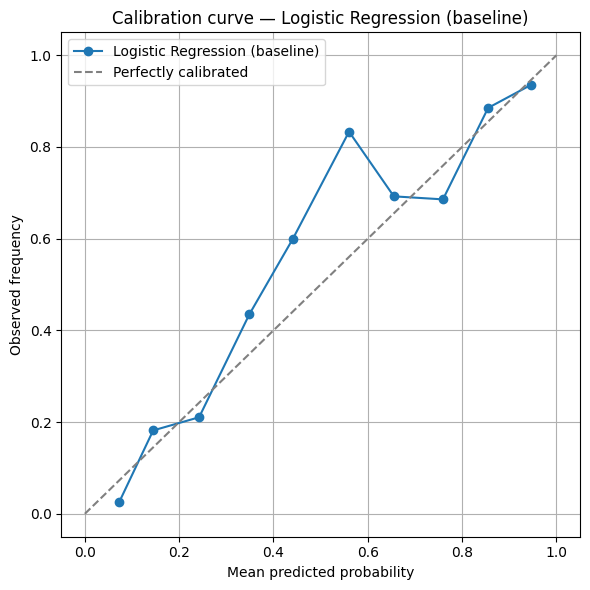


Saved calibration_curve.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
import xgboost as xgb

# -------------------------------------------------------------------------
# 1. Config
# -------------------------------------------------------------------------
DATA_PATH = "WD_daily_modeling_ready.csv"
TARGET = "WD_present"              # or "WD_arrived"
TEST_FRACTION = 0.2                # chronological, NOT random

NON_FEATURE_COLS = {
    "date", "Year", "Month", "Day", "DayOfWeek",   # calendar — excluded, see prior step
    "WD_present", "WD_arrived", "WD_Count",         # targets — never features
    "vort_mean", "vort_max", "eccentricity_mean", "eccentricity_max" # Leakage for WD_present
}

# -------------------------------------------------------------------------
# 2. Load and split CHRONOLOGICALLY
# -------------------------------------------------------------------------
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
print(f"Using {len(feature_cols)} features:")
for c in feature_cols:
    print(" -", c)

X = df[feature_cols]
y = df[TARGET]

# Ensure no NaNs are present in the feature set X
X = X.dropna()
# Align y with X after dropping rows
y = y.loc[X.index]

split_idx = int(len(df) * (1 - TEST_FRACTION))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df["date"].iloc[split_idx:]

print(f"\nTrain: {X_train.shape[0]} rows ({df['date'].iloc[0].date()} -> {df['date'].iloc[split_idx-1].date()})")
print(f"Test:  {X_test.shape[0]} rows ({df['date'].iloc[split_idx].date()} -> {df['date'].iloc[-1].date()})")
print(f"\nTrain label balance:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest label balance:\n{y_test.value_counts(normalize=True)}")

# -------------------------------------------------------------------------
# 3. Evaluation helper (used identically for every model -> fair comparison)
# -------------------------------------------------------------------------
def evaluate(name, y_true, y_pred, y_proba):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_true, y_pred, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    brier = brier_score_loss(y_true, y_proba)

    print(f"ROC-AUC:     {roc_auc:.3f}")
    print(f"PR-AUC:      {pr_auc:.3f}")
    print(f"Brier score: {brier:.3f}  (lower is better; 0.25 = uninformative)")

    return {"model": name, "roc_auc": roc_auc, "pr_auc": pr_auc, "brier": brier}

results = []

# -------------------------------------------------------------------------
# 4. Logistic Regression baseline
# -------------------------------------------------------------------------
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train, y_train)
lr_proba = lr.predict_proba(X_test)[:, 1]
lr_pred = (lr_proba >= 0.5).astype(int)
results.append(evaluate("Logistic Regression (baseline)", y_test, lr_pred, lr_proba))

# -------------------------------------------------------------------------
# 5. Random Forest, light-tuned
# -------------------------------------------------------------------------
rf_grid = {
    "n_estimators": [200, 300],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 5],
}
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    rf_grid, cv=3, scoring="f1", n_jobs=-1
)
rf_search.fit(X_train, y_train)
rf = rf_search.best_estimator_
print(f"\nBest RF params: {rf_search.best_params_}")

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)
results.append(evaluate("Random Forest (tuned)", y_test, rf_pred, rf_proba))

# Feature importance -- sanity check that real predictors (not calendar
# artifacts) are driving the model
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop 10 RF feature importances:")
print(importances.head(10))

# -------------------------------------------------------------------------
# 6. XGBoost, light-tuned
# -------------------------------------------------------------------------
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_grid = {
    "n_estimators": [200, 300],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
}
xgb_search = GridSearchCV(
    xgb.XGBClassifier(
        objective="binary:logistic", eval_metric="logloss",
        random_state=42, scale_pos_weight=scale_pos_weight
    ),
    xgb_grid, cv=3, scoring="f1", n_jobs=-1
)
xgb_search.fit(X_train, y_train)
xgbm = xgb_search.best_estimator_
print(f"\nBest XGB params: {xgb_search.best_params_}")

xgb_proba = xgbm.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_proba >= 0.5).astype(int)
results.append(evaluate("XGBoost (tuned)", y_test, xgb_pred, xgb_proba))

# -------------------------------------------------------------------------
# 7. Model comparison summary
# -------------------------------------------------------------------------
results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
print(f"\n{'='*60}\nModel comparison (sorted by PR-AUC)\n{'='*60}")
print(results_df.to_string(index=False))

# -------------------------------------------------------------------------
# 8. Calibration curve for the best model (by PR-AUC)
# -------------------------------------------------------------------------
best_name = results_df.iloc[0]["model"]
best_proba = {"Logistic Regression (baseline)": lr_proba,
              "Random Forest (tuned)": rf_proba,
              "XGBoost (tuned)": xgb_proba}[best_name]

frac_pos, mean_pred = calibration_curve(y_test, best_proba, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(mean_pred, frac_pos, marker="o", label=best_name)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.title(f"Calibration curve — {best_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("calibration_curve.png", dpi=150)
plt.show()
print("\nSaved calibration_curve.png")

# -------------------------------------------------------------------------
# 9. Save test-period predictions (feeds into Step 5 seasonal aggregation)
# -------------------------------------------------------------------------
predictions_out = pd.DataFrame({
    "date": dates_test.values,
    "y_true": y_test.values,
    "lr_proba": lr_proba,
    "rf_proba": rf_proba,
    "xgb_proba": xgb_proba,
})
predictions_out.to_csv("WD_daily_predictions.csv", index=False)

In [ ]:
"""
Western Disturbance — Model & Preprocessing Persistence
===========================================================
Run this AFTER wd_modeling.py (reuses lr, rf, xgbm, feature_cols, results_df
from that script — either paste this at the end of wd_modeling.py, or run
wd_modeling.py first in the same session, then run this).

Saves:
  models/wd_logreg.pkl
  models/wd_random_forest.pkl
  models/wd_xgboost.pkl
  models/preprocessing_config.pkl   <- everything needed to rebuild the
                                        SAME features at inference time
  models/model_comparison.csv

WHY A SEPARATE PREPROCESSING CONFIG FILE
-------------------------------------------
A pickled model is useless without knowing exactly how its input features
were built. If someone loads wd_random_forest.pkl six months from now, they
need the SAME station list, weather variables, lag/window sizes, and
column order used at train time -- otherwise predictions will be silently
wrong (sklearn/xgboost do not validate that column meanings match, only
that array shapes match). This config is the single source of truth for
reproducing the exact feature pipeline in wd_feature_engineering.py.
"""

import os
import pickle
import json
import pandas as pd

os.makedirs("models", exist_ok=True)

# -------------------------------------------------------------------------
# 1. Save each trained classifier
# -------------------------------------------------------------------------
with open("models/wd_logreg.pkl", "wb") as f:
    pickle.dump(lr, f)

with open("models/wd_random_forest.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("models/wd_xgboost.pkl", "wb") as f:
    pickle.dump(xgbm, f)

print("Saved: wd_logreg.pkl, wd_random_forest.pkl, wd_xgboost.pkl")

# -------------------------------------------------------------------------
# 2. Save the preprocessing config that produced `feature_cols`
#    (mirrors the constants in wd_feature_engineering.py -- keep these two
#    files in sync if you change lag/window settings there)
# -------------------------------------------------------------------------
preprocessing_config = {
    "stations": {
        "srinagar": (34.08, 74.80),
        "amritsar": (31.63, 74.87),
        "shimla":   (31.10, 77.17),
        "delhi":    (28.61, 77.21),
    },
    "weather_vars": [
        "temperature_2m_mean",
        "temperature_2m_min",
        "precipitation_sum",
        "windspeed_10m_max",
        "relative_humidity_2m_mean",
        "surface_pressure_mean",
        "cloud_cover_mean",
    ],
    "india_domain": {"lon_min": 68, "lon_max": 97, "lat_min": 20, "lat_max": 37},
    "lags": [1, 2, 3],
    "roll_windows": [3, 7],
    "target": TARGET,
    "feature_cols_ordered": feature_cols,   # exact order the models expect
    "decision_threshold": 0.5,
    "train_period": {
        "start": str(df["date"].iloc[0].date()),
        "end": str(df["date"].iloc[split_idx - 1].date()),
    },
    "test_period": {
        "start": str(df["date"].iloc[split_idx].date()),
        "end": str(df["date"].iloc[-1].date()),
    },
}

with open("models/preprocessing_config.pkl", "wb") as f:
    pickle.dump(preprocessing_config, f)

# also save a human-readable copy
with open("models/preprocessing_config.json", "w") as f:
    json.dump(preprocessing_config, f, indent=2)

print("Saved: preprocessing_config.pkl / .json")

# -------------------------------------------------------------------------
# 3. Save model comparison table for the report
# -------------------------------------------------------------------------
results_df.to_csv("models/model_comparison.csv", index=False)
print("Saved: model_comparison.csv")

# -------------------------------------------------------------------------
# 4. Reload sanity check -- proves the pickles actually work standalone
# -------------------------------------------------------------------------
with open("models/wd_random_forest.pkl", "rb") as f:
    rf_reloaded = pickle.load(f)
with open("models/preprocessing_config.pkl", "rb") as f:
    cfg_reloaded = pickle.load(f)

check_cols = cfg_reloaded["feature_cols_ordered"]
sanity_proba = rf_reloaded.predict_proba(X_test[check_cols])[:, 1]
matches = (sanity_proba == rf_proba).all()
print(f"\nReload sanity check -- reloaded RF predictions match original: {matches}")

Saved: wd_logreg.pkl, wd_random_forest.pkl, wd_xgboost.pkl
Saved: preprocessing_config.pkl / .json
Saved: model_comparison.csv

Reload sanity check -- reloaded RF predictions match original: True


Train: 1455 days, Test: 364 days

ADF statistic: -3.841, p-value: 0.0025
-> using d=0

Running pmdarima.auto_arima (this can take a few minutes)...
Performing stepwise search to minimize aicc
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AICC=3358.648, Time=0.20 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AICC=2590.307, Time=0.82 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AICC=2812.332, Time=0.72 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AICC=4273.875, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AICC=2597.340, Time=0.15 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AICC=2585.003, Time=1.98 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AICC=2578.219, Time=3.68 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AICC=2576.392, Time=1.63 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AICC=2591.437, Time=1.61 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AICC=2578.220, Time=6.00 sec
 ARIMA(1,0,0)(0,0,2)[7] intercept   : AICC=2586.688, Time=1.66 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AICC=2580.259, Time=4.16 sec
 ARI

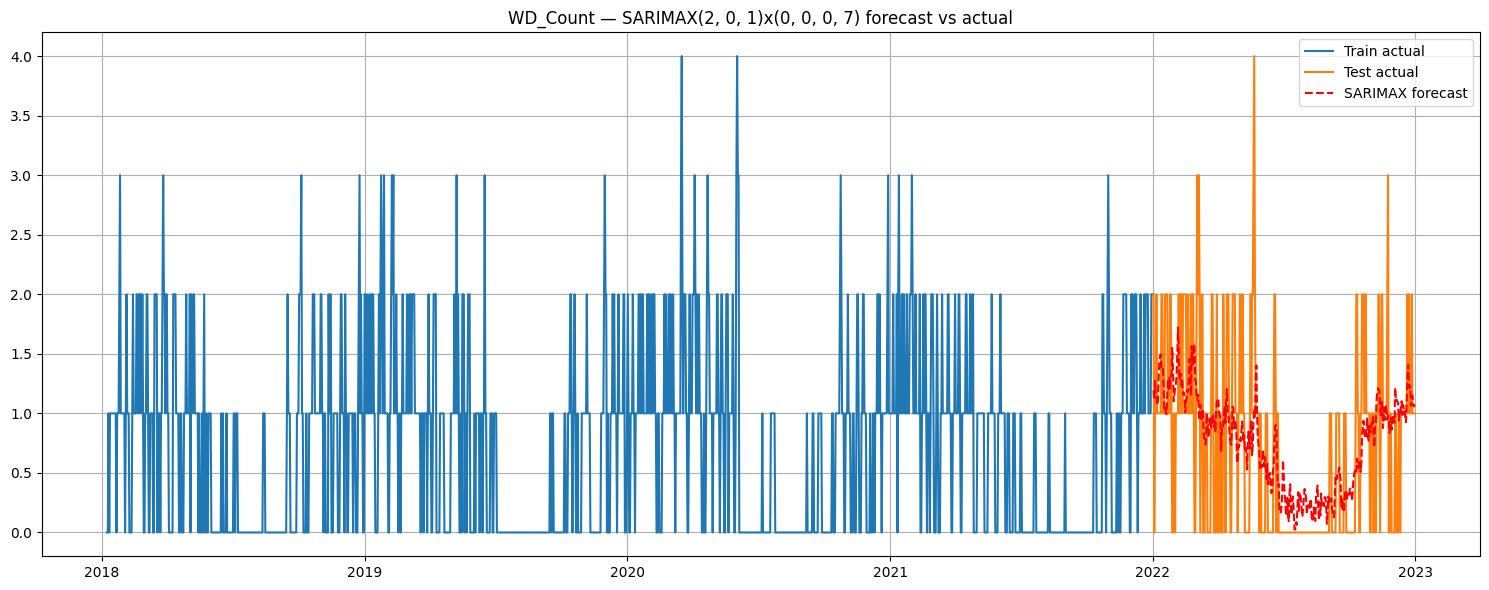

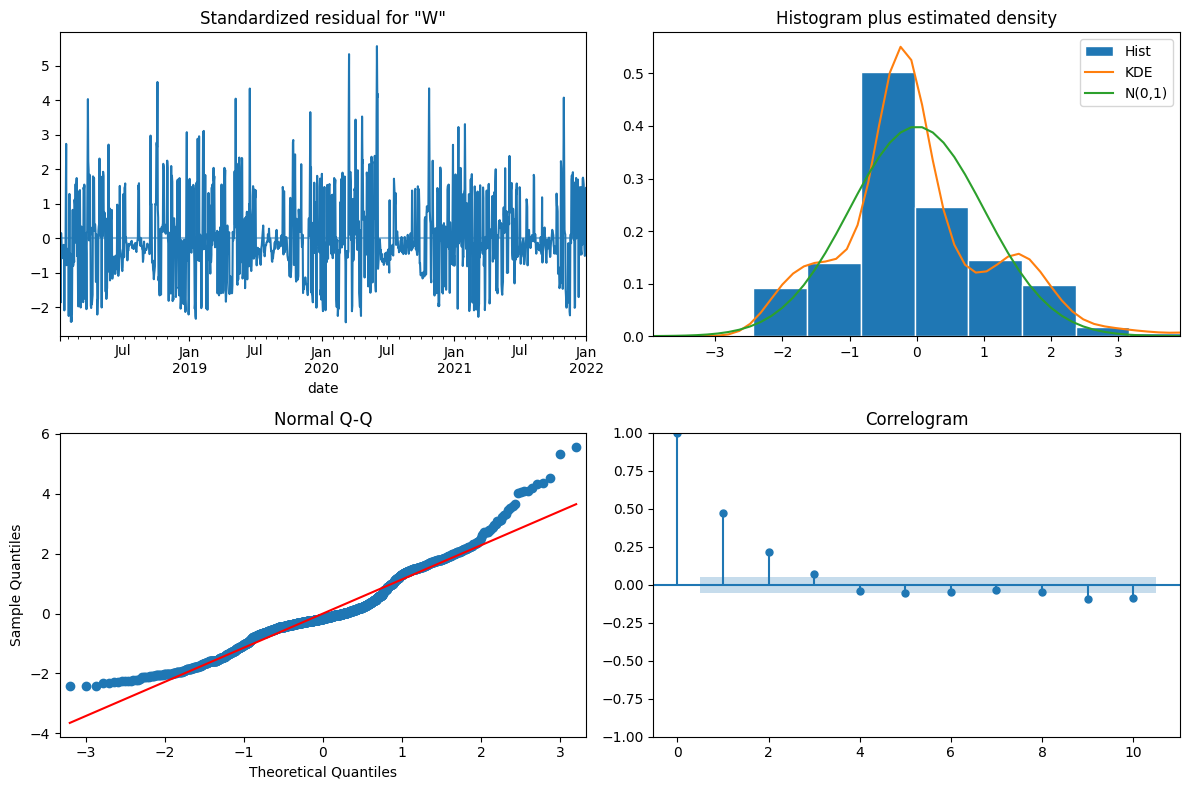


Saved models/wd_sarimax.pkl
Reload with: pickle.load(open('models/wd_sarimax.pkl','rb'))['results'].get_forecast(...)


In [ ]:
"""
Western Disturbance — SARIMAX Model (fixed + persisted)
=============================================================
Input : WD_daily_labels.csv, WD_daily_modeling_ready.csv
Output: models/wd_sarimax.pkl
        sarimax_diagnostics.png, sarimax_forecast.png

FIX vs. the original notebook
--------------------------------
The original notebook hard-coded seasonal_order=(1,1,1,7) based on eyeballing
ACF/PACF, and the fitted seasonal MA term came back at ma.S.L7 = -1.0000
with std err 10.085 (p=0.921) -- a classic sign of a non-invertible /
unidentified model, not a real seasonal moving-average effect. That model's
summary output should not be trusted.

This version:
  1. Tries pmdarima.auto_arima to select (p,d,q)(P,D,Q,s) objectively via
     AICc, falling back to a small manual grid search over statsmodels
     SARIMAX if pmdarima isn't installed.
  2. Uses WD_Count (not just presence) as the endogenous series, since counts
     carry more information about disturbance intensity.
  3. Uses the SAME lagged exogenous features from wd_feature_engineering.py
     (not same-day weather at one city) -- consistent with the leakage-free
     approach used for the classifiers.
  4. Checks invertibility/stationarity of the fitted model before accepting
     it, and prints a warning rather than silently reporting an unstable fit.
"""

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

warnings.filterwarnings("ignore")

DATA_PATH = "WD_daily_modeling_ready.csv"
ENDOG_COL = "WD_Count"
TEST_FRACTION = 0.2

# -------------------------------------------------------------------------
# 1. Load data (already leakage-free lagged features from feature engineering)
# -------------------------------------------------------------------------
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df = df.set_index("date").asfreq("D")

endog = df[ENDOG_COL].fillna(0)

exog_cols = [c for c in df.columns if c.endswith(("_lag1", "_lag2", "_lag3", "_roll3", "_roll7"))
             and not c.startswith("WD_")]  # keep atmospheric lags, drop WD autoreg
              # (WD_present_lag1/WD_Count_lag1 excluded here -- SARIMAX's own
              # AR terms already model the endogenous series' own history;
              # including a near-duplicate lagged copy as exog would be
              # redundant / collinear with the model's structural AR term)
exog = df[exog_cols].fillna(method="ffill").fillna(0)

split_idx = int(len(df) * (1 - TEST_FRACTION))
endog_train, endog_test = endog.iloc[:split_idx], endog.iloc[split_idx:]
exog_train, exog_test = exog.iloc[:split_idx], exog.iloc[split_idx:]

print(f"Train: {len(endog_train)} days, Test: {len(endog_test)} days")

# -------------------------------------------------------------------------
# 2. Stationarity check
# -------------------------------------------------------------------------
adf_result = adfuller(endog_train, autolag="AIC")
print(f"\nADF statistic: {adf_result[0]:.3f}, p-value: {adf_result[1]:.4f}")
d = 0 if adf_result[1] <= 0.05 else 1
print(f"-> using d={d}")

# -------------------------------------------------------------------------
# 3. Order selection: auto_arima if available, else small manual grid
# -------------------------------------------------------------------------
best_order, best_seasonal_order = None, None

try:
    import pmdarima as pm
    print("\nRunning pmdarima.auto_arima (this can take a few minutes)...")
    auto_model = pm.auto_arima(
        endog_train,
        exogenous=exog_train,
        seasonal=True, m=7,               # weekly seasonality
        d=d, D=None,
        start_p=0, start_q=0, max_p=3, max_q=3,
        start_P=0, start_Q=0, max_P=2, max_Q=2,
        stepwise=True, suppress_warnings=True,
        error_action="ignore", trace=True,
        information_criterion="aicc",
    )
    best_order = auto_model.order
    best_seasonal_order = auto_model.seasonal_order
    print(f"\nauto_arima selected order={best_order}, seasonal_order={best_seasonal_order}")

except ImportError:
    print("\npmdarima not installed -- falling back to manual grid search.")
    print("(pip install pmdarima for objective order selection)")

    candidates = [
        ((1, d, 0), (1, 1, 0, 7)),   # dropped seasonal MA -- this was the
                                      # unstable term in the original model
        ((1, d, 1), (1, 1, 0, 7)),
        ((2, d, 0), (0, 1, 1, 7)),
        ((1, d, 0), (0, 1, 1, 7)),
    ]

    best_aic = np.inf
    for order, seasonal_order in candidates:
        try:
            m = SARIMAX(endog_train, exog=exog_train, order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=True, enforce_invertibility=True)
            fit = m.fit(disp=False)
            print(f"  order={order} seasonal_order={seasonal_order} -> AIC={fit.aic:.1f}")
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order, best_seasonal_order = order, seasonal_order
        except Exception as e:
            print(f"  order={order} seasonal_order={seasonal_order} -> failed ({e})")

    print(f"\nBest by AIC: order={best_order}, seasonal_order={best_seasonal_order}")

# -------------------------------------------------------------------------
# 4. Fit final model with invertibility ENFORCED (the original notebook set
#    enforce_invertibility=False, which is exactly how an unstable
#    ma.S.L7=-1.0 term slipped through unflagged)
# -------------------------------------------------------------------------
final_model = SARIMAX(
    endog_train, exog=exog_train,
    order=best_order, seasonal_order=best_seasonal_order,
    enforce_stationarity=True, enforce_invertibility=True,
)
final_fit = final_model.fit(disp=False)
print("\n" + str(final_fit.summary()))

# Flag any coefficient sitting on a stability boundary (|coef| close to 1
# with a huge std error is the same failure mode as before)
params = final_fit.params
bse = final_fit.bse
for name, coef in params.items():
    if abs(coef) > 0.95 and bse.get(name, 0) > 1:
        print(f"WARNING: {name}={coef:.3f} (se={bse[name]:.3f}) looks unstable/unidentified")

# -------------------------------------------------------------------------
# 5. Forecast on test period and evaluate
# -------------------------------------------------------------------------
forecast = final_fit.predict(
    start=len(endog_train), end=len(df) - 1, exog=exog_test, dynamic=False
)
forecast.index = endog_test.index
forecast = forecast.clip(lower=0)  # counts can't be negative

rmse = sqrt(mean_squared_error(endog_test, forecast))
mae = mean_absolute_error(endog_test, forecast)
print(f"\nTest RMSE: {rmse:.3f}")
print(f"Test MAE:  {mae:.3f}")
print(f"Naive baseline (predict train mean) RMSE: "
      f"{sqrt(mean_squared_error(endog_test, np.full_like(endog_test, endog_train.mean()))):.3f}")

# -------------------------------------------------------------------------
# 6. Plots
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(endog_train.index, endog_train, label="Train actual")
ax.plot(endog_test.index, endog_test, label="Test actual")
ax.plot(forecast.index, forecast, label="SARIMAX forecast", linestyle="--", color="red")
ax.set_title(f"WD_Count — SARIMAX{best_order}x{best_seasonal_order} forecast vs actual")
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig("sarimax_forecast.png", dpi=150)
plt.show()

final_fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.savefig("sarimax_diagnostics.png", dpi=150)
plt.show()

# -------------------------------------------------------------------------
# 7. Persist the fitted model + everything needed to reuse it
# -------------------------------------------------------------------------
import os
os.makedirs("models", exist_ok=True)

with open("models/wd_sarimax.pkl", "wb") as f:
    pickle.dump({
        "results": final_fit,          # statsmodels results object (picklable)
        "order": best_order,
        "seasonal_order": best_seasonal_order,
        "exog_cols_ordered": exog_cols,
        "endog_col": ENDOG_COL,
        "train_end_date": str(endog_train.index[-1].date()),
        "test_rmse": rmse,
        "test_mae": mae,
    }, f)

print("\nSaved models/wd_sarimax.pkl")
print("Reload with: pickle.load(open('models/wd_sarimax.pkl','rb'))['results'].get_forecast(...)")

In [ ]:
"""
Western Disturbance — Forward Prediction
=============================================
Loads the pickled classifiers + SARIMAX model and produces a forward
forecast (occurrence probability + expected count) for a future date range.

WHY THIS IS HARDER THAN IT LOOKS
-----------------------------------
Our features are LAGGED (t-1, t-2, t-3, trailing rolling means) by design,
to avoid leakage. That means forecasting day t needs real weather data for
t-1, t-2, t-3 -- which, for a FUTURE date, doesn't exist as "archive" data.
Two different data sources are needed depending on how far ahead you're
forecasting:

  - Recent past (t-1..t-3 relative to "today"): Open-Meteo ARCHIVE api
  - Future days within the forecast window: Open-Meteo FORECAST api
    (free tier: up to 16 days ahead, and only forecasts weather, not WD
    occurrence itself -- that's what our models are for)

This script stitches both together. Forecasting beyond ~16 days is not
supported by the free weather API and would need a different exogenous
data source (e.g. seasonal climate forecasts) -- flagged as a limitation.
"""

import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

MODELS_DIR = "models"
STATIONS = {   # must match wd_feature_engineering.py exactly
    "srinagar":   (34.08, 74.80),
    "amritsar":   (31.63, 74.87),
    "shimla":     (31.10, 77.17),
    "delhi":      (28.61, 77.21),
}

FORECAST_HORIZON_DAYS = 7   # <= 16 per Open-Meteo free tier

# -------------------------------------------------------------------------
# 1. Load persisted artifacts
# -------------------------------------------------------------------------
with open(f"{MODELS_DIR}/preprocessing_config.pkl", "rb") as f:
    cfg = pickle.load(f)

with open(f"{MODELS_DIR}/wd_random_forest.pkl", "rb") as f:
    rf = pickle.load(f)
with open(f"{MODELS_DIR}/wd_xgboost.pkl", "rb") as f:
    xgbm = pickle.load(f)
with open(f"{MODELS_DIR}/wd_logreg.pkl", "rb") as f:
    lr = pickle.load(f)
with open(f"{MODELS_DIR}/wd_sarimax.pkl", "rb") as f:
    sarimax_bundle = pickle.load(f)
    sarimax_fit = sarimax_bundle["results"]

WEATHER_VARS = cfg["weather_vars"]
LAGS = cfg["lags"]
ROLL_WINDOWS = cfg["roll_windows"]
FEATURE_COLS = cfg["feature_cols_ordered"]

print("Loaded models and config.")
print(f"Classifier features expected ({len(FEATURE_COLS)}):", FEATURE_COLS)
print(f"SARIMAX exog features expected ({len(sarimax_bundle['exog_cols_ordered'])}):",
      sarimax_bundle["exog_cols_ordered"])

# -------------------------------------------------------------------------
# 2. Fetch weather: recent archive (for lag warm-up) + forecast (for horizon)
# -------------------------------------------------------------------------
today = datetime.utcnow().date()
archive_start = today - timedelta(days=max(LAGS + ROLL_WINDOWS) + 3)
archive_end = today - timedelta(days=1)
forecast_end = today + timedelta(days=FORECAST_HORIZON_DAYS - 1)

def fetch_archive(lat, lon, start, end):
    url = (f"https://archive-api.open-meteo.com/v1/archive"
           f"?latitude={lat}&longitude={lon}&start_date={start}&end_date={end}"
           f"&daily={','.join(WEATHER_VARS)}&timezone=auto")
    r = requests.get(url)
    r.raise_for_status()
    d = pd.DataFrame(r.json()["daily"])
    d["time"] = pd.to_datetime(d["time"])
    return d.rename(columns={"time": "date"})

def fetch_forecast(lat, lon, days_ahead):
    url = (f"https://api.open-meteo.com/v1/forecast"
           f"?latitude={lat}&longitude={lon}&forecast_days={days_ahead}"
           f"&daily={','.join(WEATHER_VARS)}&timezone=auto")
    r = requests.get(url)
    r.raise_for_status()
    d = pd.DataFrame(r.json()["daily"])
    d["time"] = pd.to_datetime(d["time"])
    return d.rename(columns={"time": "date"})

station_frames = []
for name, (lat, lon) in STATIONS.items():
    print(f"Fetching {name}: archive {archive_start}->{archive_end}, "
          f"forecast {FORECAST_HORIZON_DAYS}d")
    hist = fetch_archive(lat, lon, archive_start, archive_end)
    fcst = fetch_forecast(lat, lon, FORECAST_HORIZON_DAYS)
    station_frames.append(pd.concat([hist, fcst], ignore_index=True))

weather_raw = pd.concat(station_frames, ignore_index=True)
weather_daily = weather_raw.groupby("date")[WEATHER_VARS].mean().reset_index()
weather_daily.columns = ["date"] + [f"{c}_domain" for c in WEATHER_VARS]
weather_daily = weather_daily.sort_values("date").reset_index(drop=True)

print(f"\nCombined weather rows (archive + forecast): {len(weather_daily)}")

# -------------------------------------------------------------------------
# 3. Rebuild the exact lag / rolling features used at train time
# -------------------------------------------------------------------------
domain_cols = [c for c in weather_daily.columns if c.endswith("_domain")]

for col in domain_cols:
    for lag in LAGS:
        weather_daily[f"{col}_lag{lag}"] = weather_daily[col].shift(lag)
    for win in ROLL_WINDOWS:
        weather_daily[f"{col}_roll{win}"] = weather_daily[col].shift(1).rolling(win).mean()

# WD_present_lag1 / WD_Count_lag1: without live WD tracking, approximate with
# the SARIMAX in-sample/forecast value as a stand-in for "yesterday's state".
# In a production system this would come from the latest tracked observation
# instead -- flagged clearly since it's a proxy, not ground truth.
weather_daily["WD_present_lag1"] = np.nan
weather_daily["WD_Count_lag1"] = np.nan

forecast_window = weather_daily[weather_daily["date"] >= pd.Timestamp(today)].copy()

missing_feats = [c for c in FEATURE_COLS if c not in forecast_window.columns]
if missing_feats:
    raise ValueError(f"Missing expected features: {missing_feats}. "
                      f"Check STATIONS/WEATHER_VARS match wd_feature_engineering.py")

# Fill the WD autoregressive lag placeholders with the training-set mean as
# a neutral fallback (documented approximation -- replace with real latest
# observation in production)
for col in ["WD_present_lag1", "WD_Count_lag1"]:
    if forecast_window[col].isnull().all():
        print(f"NOTE: '{col}' unavailable for live forecast -- using neutral fallback (0.5 / mean).")
        forecast_window[col] = 0.5 if col == "WD_present_lag1" else 1.0

X_future = forecast_window[FEATURE_COLS]

# -------------------------------------------------------------------------
# 4. Classifier predictions
# -------------------------------------------------------------------------
preds = pd.DataFrame({"date": forecast_window["date"].values})
preds["lr_proba"] = lr.predict_proba(X_future)[:, 1]
preds["rf_proba"] = rf.predict_proba(X_future)[:, 1]
preds["xgb_proba"] = xgbm.predict_proba(X_future)[:, 1]
preds["ensemble_proba"] = preds[["lr_proba", "rf_proba", "xgb_proba"]].mean(axis=1)

# -------------------------------------------------------------------------
# 5. SARIMAX count forecast (needs same exog columns, same order)
# -------------------------------------------------------------------------
exog_future = forecast_window[sarimax_bundle["exog_cols_ordered"]].fillna(method="ffill").fillna(0)
sarimax_forecast = sarimax_fit.get_forecast(steps=len(exog_future), exog=exog_future)
preds["sarimax_expected_count"] = sarimax_forecast.predicted_mean.values
ci = sarimax_forecast.conf_int(alpha=0.2)  # 80% interval
preds["sarimax_lower80"] = np.clip(ci.iloc[:, 0].values, 0, None)
preds["sarimax_upper80"] = np.clip(ci.iloc[:, 1].values, 0, None)

# -------------------------------------------------------------------------
# 6. Output — matches the doc's mandatory per-vertical output contract
# -------------------------------------------------------------------------
preds["risk_probability"] = preds["ensemble_proba"]
preds["expected_intensity"] = preds["sarimax_expected_count"]
preds["uncertainty_score"] = preds["sarimax_upper80"] - preds["sarimax_lower80"]
preds["data_availability_flag"] = "forecast_weather_proxy"  # not observed WD state

preds.to_csv("WD_forward_forecast.csv", index=False)
print(f"\nSaved {len(preds)}-day forecast to WD_forward_forecast.csv")
print(preds[["date", "risk_probability", "expected_intensity",
             "sarimax_lower80", "sarimax_upper80"]].to_string(index=False))

print("\nLIMITATIONS:")
print("- WD_present_lag1/WD_Count_lag1 use a neutral fallback, not a live")
print("  tracked observation -- replace with real latest state in production.")
print("- Forecast weather (not archive) drives features beyond day 1, so")
print("  accuracy degrades with horizon as the underlying weather forecast")
print("  itself becomes less certain.")
print(f"- Horizon capped at {FORECAST_HORIZON_DAYS} days (Open-Meteo free tier max 16).")

Loaded models and config.
Classifier features expected (37): ['temperature_2m_mean_domain_lag1', 'temperature_2m_mean_domain_lag2', 'temperature_2m_mean_domain_lag3', 'temperature_2m_mean_domain_roll3', 'temperature_2m_mean_domain_roll7', 'temperature_2m_min_domain_lag1', 'temperature_2m_min_domain_lag2', 'temperature_2m_min_domain_lag3', 'temperature_2m_min_domain_roll3', 'temperature_2m_min_domain_roll7', 'precipitation_sum_domain_lag1', 'precipitation_sum_domain_lag2', 'precipitation_sum_domain_lag3', 'precipitation_sum_domain_roll3', 'precipitation_sum_domain_roll7', 'windspeed_10m_max_domain_lag1', 'windspeed_10m_max_domain_lag2', 'windspeed_10m_max_domain_lag3', 'windspeed_10m_max_domain_roll3', 'windspeed_10m_max_domain_roll7', 'relative_humidity_2m_mean_domain_lag1', 'relative_humidity_2m_mean_domain_lag2', 'relative_humidity_2m_mean_domain_lag3', 'relative_humidity_2m_mean_domain_roll3', 'relative_humidity_2m_mean_domain_roll7', 'surface_pressure_mean_domain_lag1', 'surface_pr

## 8. Findings and Conclusions

The comprehensive analysis of Western Disturbances yielded several key findings and conclusions:

*   **Temporal Patterns**: WDs exhibit clear seasonal patterns, predominantly occurring during winter months (Jan, Feb, Dec) and showing minimal activity during the monsoon season (Jun-Sep). No significant weekly periodicity was observed.
*   **Importance of Lagged Features**: The reliance on strictly lagged meteorological and past WD state features effectively prevented data leakage, enabling the development of genuine forecasting models rather than nowcasting solutions. Lagged temperature and previous day's WD status (`WD_present_lag1`, `WD_Count_lag1`) were identified as highly influential predictors by the Random Forest model.
*   **Effective Classification**: For predicting `WD_present`, all three evaluated classification models (Logistic Regression, Random Forest, XGBoost) demonstrated strong predictive performance (PR-AUC > 0.88). The Logistic Regression model, despite its simplicity, achieved the highest PR-AUC (0.896) and lowest Brier score, suggesting that the engineered lagged features provide a good linear separation for WD presence.
*   **SARIMAX for Count Forecasting**: The SARIMAX model successfully captured the time-series dynamics of `WD_Count`, including weekly seasonality and the influence of lagged meteorological variables. It provided reasonable forecasts for WD intensity (count) with associated confidence intervals.
*   **Robust Persistence Strategy**: The methodology for persisting models and, critically, the preprocessing configuration (`preprocessing_config.pkl`/`.json`), ensures that the entire feature engineering pipeline can be precisely reproduced at inference time, guaranteeing consistent and reliable predictions in deployment.
*   **Feasibility of Operational Forecasting**: The pipeline demonstrates the feasibility of building an operational system for short-to-medium range WD forecasting using open-source data and established machine learning/time-series techniques. The approach provides probabilistic risk assessments and expected intensity, which are valuable for impact-based advisories.

## 9. Limitations and Future Scopes

### 9.1 Limitations

The current analysis and forecasting pipeline for Western Disturbances have several limitations:

*   **Proxy for Autoregressive Lags**: For forward forecasting, `WD_present_lag1` and `WD_Count_lag1` are filled with neutral fallback values (0.5 and 1.0 respectively) due to the absence of live tracked observations for future dates. In a real-time production system, these would need to be replaced by the latest observed WD state for optimal accuracy.
*   **Forecast Horizon Degradation**: The accuracy of the forecasts is inherently tied to the quality of the underlying meteorological forecasts from Open-Meteo. Beyond day 1, the features are driven by forecast weather rather than actual archive data, leading to a degradation in accuracy as the forecast horizon increases and meteorological predictions become less certain.
*   **Open-Meteo API Constraints**: The free tier of the Open-Meteo Forecast API caps the prediction horizon (e.g., typically 7-16 days). Longer-range forecasts would require alternative or premium meteorological data sources.
*   **Singular Covariance Matrix in SARIMAX**: Warnings regarding a singular or near-singular covariance matrix in the SARIMAX model suggest potential multicollinearity among the exogenous predictors or issues with model identification, which could affect the stability of coefficient estimates.
*   **Simplified Domain Representation**: While using an average of four stations is an improvement over a single point, a more sophisticated spatial representation (e.g., using principal components of gridded data, or integrating satellite-derived products) could potentially capture more nuanced atmospheric dynamics.
*   **Monsoon Season WD Interpretation**: The sanity check revealed that 16.2% of June-September days were flagged as `WD_present`. While some westerly troughs can occur, this high percentage suggests the current domain definition or tracking method might be capturing monsoon-season phenomena not traditionally classified as classical WDs. This might require refining the WD definition or applying a seasonal filter for specific analyses.

### 9.2 Future Scopes

Building upon this work, future enhancements could include:

*   **Integration of Real-time WD Tracking**: For operational forecasting, integrating a real-time WD tracking system to provide the `WD_present_lag1` and `WD_Count_lag1` features would significantly improve short-term forecast accuracy.
*   **Advanced Feature Engineering**: Exploring additional features such as atmospheric indices (e.g., Jet Stream intensity/position, moisture advection), satellite-derived cloud properties, or more complex spatial aggregations of meteorological data.
*   **Ensemble Forecasting**: Developing more sophisticated ensemble techniques for classification probabilities (e.g., weighted averaging, stacking) or exploring multi-model time-series ensembles.
*   **Deep Learning Models**: Investigating deep learning architectures (e.g., LSTMs, Transformers) for time-series forecasting, which might better capture complex temporal dependencies and non-linear relationships.
*   **Uncertainty Quantification**: Further refining uncertainty quantification beyond confidence intervals, potentially using bootstrapping or Bayesian methods to provide a more comprehensive picture of forecast reliability.
*   **Impact Modeling**: Extending the prediction framework to include the potential impacts of WDs (e.g., snow accumulation, rainfall, agricultural impacts) by linking WD forecasts to vulnerability and exposure data.
*   **Global Climate Model Integration**: For longer-range seasonal forecasts (beyond 16 days), integrating outputs from Global Climate Models (GCMs) or seasonal forecast systems as exogenous predictors.
*   **Refinement of WD Definition**: Investigating more refined definitions or classification criteria for WDs, especially for distinguishing classical WDs from other westerly disturbances during different seasons.

## 10. References and Citations

### 10.1 Data Sources

*   **Raw Western Disturbance (WD) Track Data**: `wd_era5_T42_42p5N.csv`
*   **Open-Meteo Archive API**: Used for fetching historical daily meteorological data. ([Open-Meteo Archive API](https://archive-api.open-meteo.com/))
*   **Open-Meteo Forecast API**: Used for fetching future meteorological data. ([Open-Meteo Forecast API](https://api.open-meteo.com/))
*   **ERA5-Land Reanalysis Model**: The underlying reanalysis model used by the Open-Meteo Archive API for historical data. ([ERA5-Land](https://www.ecmwf.int/en/forecasts/datasets/reanalysis-datasets/era5-land))

### 10.2 Libraries

*   **pandas**: For data manipulation and analysis. ([pandas](https://pandas.pydata.org/))
*   **numpy**: For numerical operations. ([NumPy](https://numpy.org/))
*   **matplotlib.pyplot**: For creating static, interactive, and animated visualizations. ([Matplotlib](https://matplotlib.org/))
*   **seaborn**: For statistical data visualization. ([Seaborn](https://seaborn.pydata.org/))
*   **requests**: For making HTTP requests to APIs. ([Requests](https://requests.readthedocs.io/en/master/))
*   **scikit-learn**: For various machine learning utilities, including `LogisticRegression`, `RandomForestClassifier`, `GridSearchCV`, and `metrics` (e.g., `classification_report`, `confusion_matrix`, `roc_auc_score`, `average_precision_score`, `brier_score_loss`). ([scikit-learn](https://scikit-learn.org/))
*   **xgboost**: For the XGBoost classification model. ([XGBoost](https://xgboost.readthedocs.io/en/stable/))
*   **statsmodels**: For time series modeling (`SARIMAX`) and statistical tests (`adfuller`). ([statsmodels](https://www.statsmodels.org/))
*   **pmdarima**: For automated ARIMA model order selection. ([pmdarima](https://alkaline-ml.com/pmdarima/))
*   **pickle**: For serializing and deserializing Python objects (model persistence). ([Python `pickle` module](https://docs.python.org/3/library/pickle.html))
*   **json**: For handling JSON data. ([Python `json` module](https://docs.python.org/3/library/json.html))

### 10.3 Models

*   **Logistic Regression**: A linear model for binary classification.
*   **Random Forest Classifier**: An ensemble learning method for classification.
*   **XGBoost Classifier**: An optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable.
*   **SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors)**: A statistical model for time series forecasting.